In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pylab as pl

from cgt_perezsechi.visualization.plot import plot_shap_distribution
from cgt_perezsechi.modeling.inequality import gini_coefficient
from cgt_perezsechi.visualization.plot import plot_shap_lorenz_curve

In [2]:
X = pd.read_pickle("../../data/shap/x_values.pkl")
num_patients = 500
X_shapley = X.iloc[:num_patients, :]
shap_values = np.load("../../data/shap/shap_values.npy")
shap_interaction_values = np.load("../../data/shap/shap_interaction_values.npy")
abs_shap_values = np.abs(shap_values)
n_bins = 100

## Distribución con respecto a la suma parcial de las variables

In [3]:
top_variables = [
    "age",
    "sex_isFemale",
    "systolic_blood_pressure",
    # "bmi",
    # "urine_albumin_isNegative",
    # "pulse_pressure",
    # "rand"
]

Variable: age


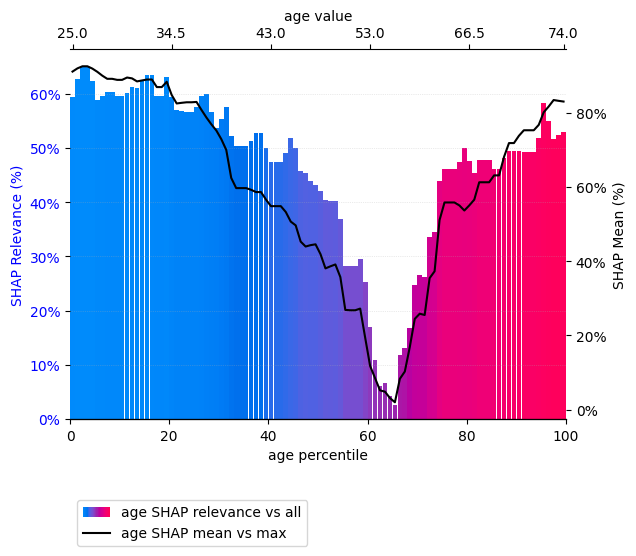

Minimum relevance where age equals 56.170000000000016
Variable: sex_isFemale


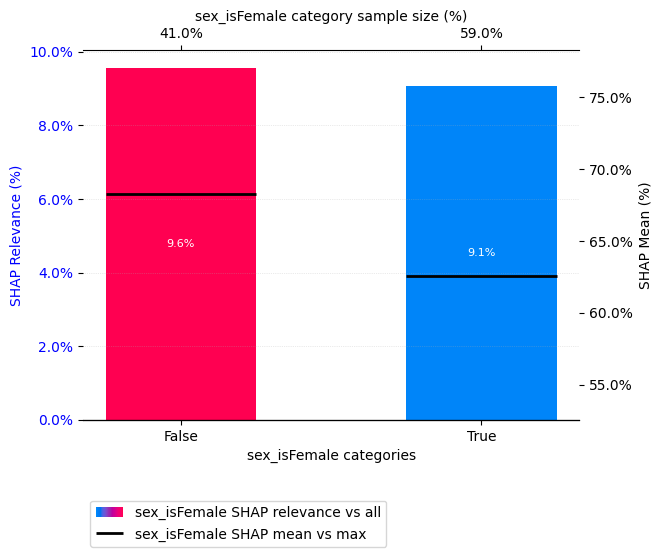

Minimum relevance where sex_isFemale equals 59.0%
Variable: systolic_blood_pressure


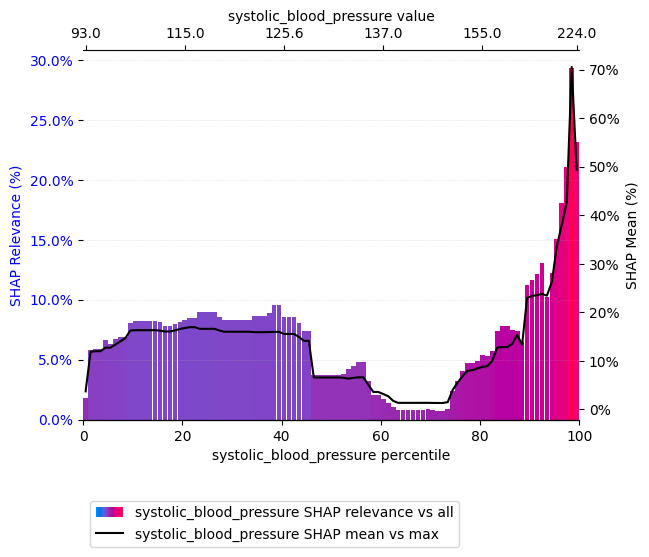

Minimum relevance where systolic_blood_pressure equals 144.0


In [5]:
for variable_name in top_variables:
    print(f"Variable: {variable_name}")
    results = plot_shap_distribution(variable_name, X_shapley, shap_values, n_bins)
    min_index = np.argmin(results["abs_shap_relevance"])
    print(f"Minimum relevance where {variable_name} equals {results['variable_label'][min_index]}")

Gini coefficient for age SHAP values: 0.2455


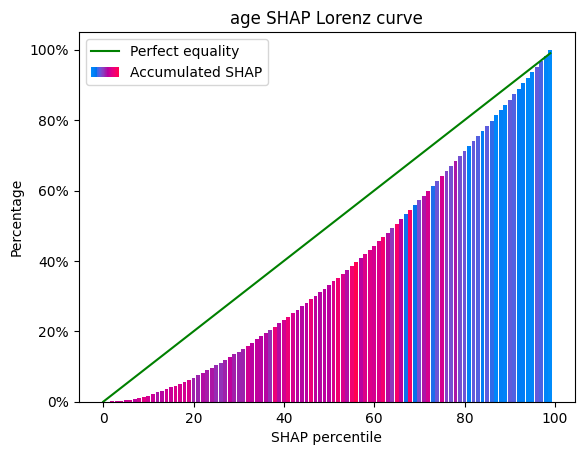

Gini coefficient for sex_isFemale SHAP values: 0.1238


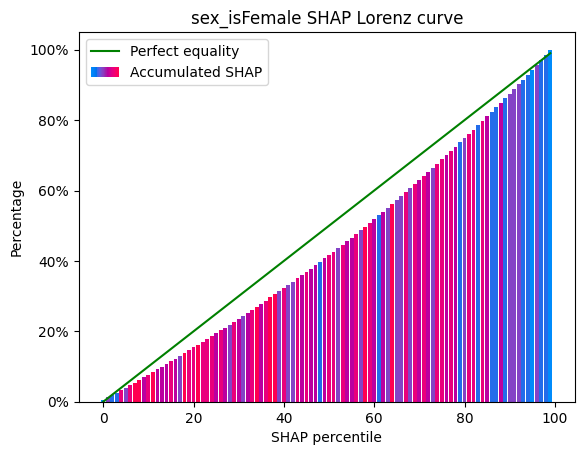

Gini coefficient for systolic_blood_pressure SHAP values: 0.3820


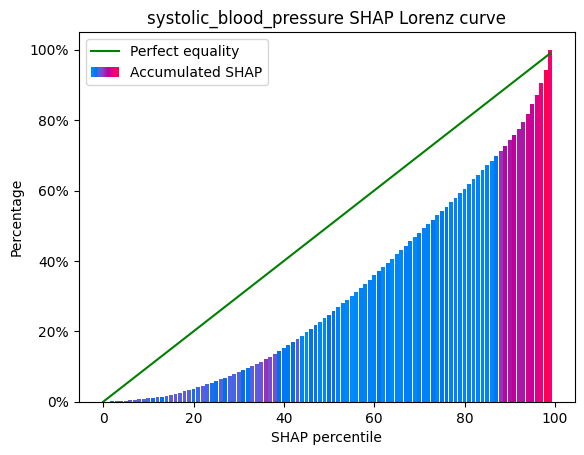

In [19]:
for variable_name in top_variables:
    variable_index = X_shapley.columns.get_loc(variable_name)
    variable_shap_values = abs_shap_values[:, variable_index]

    gini_index = gini_coefficient(variable_shap_values)
    print(f"Gini coefficient for {variable_name} SHAP values: {gini_index:.4f}")
    plot_shap_lorenz_curve(variable_name, X_shapley, abs_shap_values, n_bins)